In [1]:
import os
os.listdir()

['.ipynb_checkpoints',
 'AGRUPAMENTO-BOs-CD2.ipynb',
 'Agrupamento_de_BOs-teste.ipynb',
 'Agrupamento_de_BOs-teste2.ipynb',
 'Agrupamento_de_BOs.ipynb',
 'Alvos - Furto - Jan 2015 a Dez 2017.csv',
 'Alvos - Furto - Jan 2018 a Dez 2021.csv',
 'Alvos - Furto - Jan 2022 a Dez 2025.csv',
 'Alvos - Roubo - Jan 2015 a Dez 2025.csv',
 'clusters_municipios_perfil_temporal.csv',
 'clusters_tipos_crime.csv',
 'Crimes Violentos - Jan 2012 a Dez 2021.csv',
 'Crimes Violentos - Jan 2022 a Dez 2025.csv',
 'fuckmeeyes.ipynb',
 'fuckmeeyes2-FINAL.ipynb',
 'fuckmeeyes2.ipynb',
 'Furto - Jan 2012 a Dez 2014.csv',
 'Furto - Jan 2015 a Dez 2017.csv',
 'Furto - Jan 2018 a Dez 2021.csv',
 'Furto - Jan 2022 a Dez 2025.csv',
 'Lesão Corporal - Jan 2012 a Dez 2018.csv',
 'Lesão Corporal - Jan 2019 a Dez 2025.csv',
 'Veiculos - Furto - Jan 2015 a Dez 2025.csv',
 'Veiculos - Roubo - Jan 2015 a Dez 2025.csv',
 'Vítimas de Homicidio Consumado - Jan 2012 a Dez 2025.csv']

# Agrupamento de Boletins de Ocorrência (MG)
Este notebook analisa padrões temporais, espaciais e tipológicos da criminalidade a partir de dados agregados de boletins de ocorrência.

## Objetivos
- Identificar padrões por dia da semana e faixa horária.
- Avaliar a relação entre uso de arma de fogo e contexto temporal/regional.
- Avaliar associação entre tipo de local e crimes violentos.
- Segmentar municípios por perfil temporal com K-Means.

## Observações
- A base é agregada e usa `qtde ocorrencias` como peso.
- As métricas e proporções devem ser interpretadas de forma ponderada.

In [2]:
mapa_colunas = {
    "número reds": "numero_reds",
    "qtde ocorrências": "qtde ocorrencias",
    "natureza principal completa": "natureza_principal_completa",
    "ano": "ano",

    "mês fato resumido": "mes_fato_resumido",
    "mês numérico fato": "mes",
    "data fato": "data_fato",
    "dia da semana fato": "dia_semana_fato",

    "horário fato": "horario_fato",
    "faixa 1 hora fato": "faixa_1h_fato",
    "faixa 6 horas fato": "faixa_6h_fato",

    "alvo": "alvo",
    "causa presumida": "causa_presumida",

    "desc longa meio utilizado": "descricao_longa_meio_utilizado",
    "descrição grupo local imediato": "descricao_grupo_local_imediato",
    "descrição local imediato": "descricao_local_imediato",

    "logradouro ocorrência - tipo": "tipo_logradouro_ocorrencia",
    "bairro - fato final": "bairro_fato",
    "bairro - fato final - municipio": "bairro_municipio",

    "municipio": "municipio",
    "município - código": "codigo_municipio",
    "uf - sigla": "uf",

    "risp": "risp",
    "rmbh": "rmbh",

    "descrição meio utilizado": "descricao_meio_utilizado",
    "qtde veículos": "quantidade_veiculos",
    "tipo veículo": "tipo_veiculo",
    "situação veículo": "situacao_veiculo",

    "qtd envolvidos": "quantidade_envolvidos",
    "descrição subclasse nat principal": "subclasse_natureza_principal",
    "tentado/consumado nat principal": "tentado_consumado",
    "natureza principal final": "natureza_principal_final",
    "natureza nomenclatura banco": "natureza_banco",

    "tipo_envolvimento_lesão_final": "tipo_envolvimento_lesao",
    "idade aparente": "idade_aparente",
    "sexo": "sexo",
    "cútis": "cutis",
    "escolaridade": "escolaridade",
    "relação vítima/autor": "relacao_vitima_autor",

    "tipo logradouro envolvido": "tipo_logradouro_envolvido",
    "bairro envolvido": "bairro_envolvido",
    "município envolvido": "municipio_envolvido",
    "uf envolvido - nome": "uf_envolvido"
}

colunas_remover = [
    "numero reds",
    "mes fato resumido",
    "mes numerico fato",
    "ano fato",
    "faixa_1h_fato",
    "faixa_6h_fato",
    "descricao grupo local imediato",
    "bairro_municipio",
    "municipio - codigo",
    "uf",
    "tipo_logradouro_envolvido",
    "bairro_envolvido",
    "municipio envolvido",
    "uf_envolvido"
]



In [3]:
import pandas as pd
import glob
import unicodedata

def padronizar_nome_coluna(col):
    col = col.strip().lower()
    col = unicodedata.normalize('NFKD', col).encode('ascii', 'ignore').decode('utf-8')
    col = col.replace('\ufeff', '')
    return col

arquivos_csv = glob.glob("*.csv")

datasets = []

for arquivo in arquivos_csv:
    
    try:
        df = pd.read_csv(arquivo, sep=";", encoding="utf-8", low_memory=False)
        
    except UnicodeDecodeError:
        try:
            df = pd.read_csv(arquivo, sep=";", encoding="latin1", low_memory=False)
            
        except UnicodeDecodeError:
            df = pd.read_csv(arquivo, sep=";", encoding="ISO-8859-1", low_memory=False)

    # padroniza nomes das colunas
    df.columns = [padronizar_nome_coluna(c) for c in df.columns]

    # aplica renomeação
    df.rename(columns=mapa_colunas, inplace=True)

    # remove colunas não utilizadas
    df.drop(columns=colunas_remover, inplace=True, errors="ignore")

    datasets.append(df)

dataset_combinado = pd.concat(datasets, ignore_index=True)

print("Arquivos lidos com sucesso")
print(dataset_combinado.shape)
print(dataset_combinado.columns)

Arquivos lidos com sucesso
(9830647, 31)
Index(['qtde ocorrencias', 'natureza_principal_completa', 'data_fato',
       'dia_semana_fato', 'horario fato', 'alvo', 'causa_presumida',
       'descricao_longa_meio_utilizado', 'descricao local imediato',
       'logradouro ocorrencia - tipo', 'bairro_fato', 'municipio', 'risp',
       'rmbh',
       'municipio,madrugada,manha,noite,tarde,cluster,dist_to_centroid',
       'natureza_principal_completa,madrugada,manha,noite,tarde,cluster,dist_to_centroid',
       'descricao meio utilizado', 'qtde veiculos', 'tipo veiculo',
       'situacao veiculo', 'quantidade_envolvidos',
       'descricao subclasse nat principal', 'tentado_consumado',
       'natureza_principal_final', 'natureza_banco',
       'tipo_envolvimento_lesao_final', 'idade_aparente', 'sexo', 'cutis',
       'escolaridade', 'relacao vitima/autor'],
      dtype='str')


In [4]:
dataset_combinado.info()
dataset_combinado.describe()

dataset_combinado.isnull().sum()  # Mostra a quantidade de valores nulos.
dataset_combinado.columns = dataset_combinado.columns.str.strip().str.lower()

<class 'pandas.DataFrame'>
RangeIndex: 9830647 entries, 0 to 9830646
Data columns (total 31 columns):
 #   Column                                                                            Dtype  
---  ------                                                                            -----  
 0   qtde ocorrencias                                                                  float64
 1   natureza_principal_completa                                                       str    
 2   data_fato                                                                         str    
 3   dia_semana_fato                                                                   object 
 4   horario fato                                                                      str    
 5   alvo                                                                              str    
 6   causa_presumida                                                                   str    
 7   descricao_longa_meio_utilizado        

In [5]:
threshold = 0.8
cols_to_drop = dataset_combinado.columns[dataset_combinado.isnull().mean() > threshold]

print("Colunas removidas por excesso de nulos:")
print(cols_to_drop.tolist())

dataset_combinado = dataset_combinado.drop(columns=cols_to_drop)

Colunas removidas por excesso de nulos:
['municipio,madrugada,manha,noite,tarde,cluster,dist_to_centroid', 'natureza_principal_completa,madrugada,manha,noite,tarde,cluster,dist_to_centroid', 'qtde veiculos', 'tipo veiculo', 'situacao veiculo', 'quantidade_envolvidos', 'descricao subclasse nat principal', 'tentado_consumado', 'natureza_principal_final', 'natureza_banco', 'tipo_envolvimento_lesao_final', 'idade_aparente', 'sexo', 'cutis', 'escolaridade', 'relacao vitima/autor']


In [6]:
# Verifica se as colunas essenciais estão disponíveis.
colunas_criticas = [
    "qtde ocorrencias",
    "data_fato",
    "dia_semana_fato",
    "horario fato",
    "natureza_principal_completa",
    "descricao_longa_meio_utilizado",
    "municipio",
    "risp"
]

faltantes = [c for c in colunas_criticas if c not in dataset_combinado.columns]

print("Colunas críticas faltantes:", faltantes if faltantes else "Nenhuma")
print("Total de colunas atuais:", len(dataset_combinado.columns))

Colunas críticas faltantes: Nenhuma
Total de colunas atuais: 15


In [7]:
import pandas as pd
import numpy as np

# Limpa valores inválidos da coluna de data.
dataset_combinado['data_fato_limpa'] = (
    dataset_combinado['data_fato']
    .astype(str)
    .str.strip()
    .replace(['nan', 'NaN', 'None', 'NULL', 'null', '', '-', '--', '0000-00-00', '00/00/0000'], np.nan)
)

# Primeiro tenta converter datas no formato ISO.
dataset_combinado['data_fato_dt'] = pd.to_datetime(
    dataset_combinado['data_fato_limpa'],
    errors='coerce'
)

# Depois tenta converter as datas restantes no formato dia/mês/ano.
mask_ainda_nulo = dataset_combinado['data_fato_dt'].isna() & dataset_combinado['data_fato_limpa'].notna()

dataset_combinado.loc[mask_ainda_nulo, 'data_fato_dt'] = pd.to_datetime(
    dataset_combinado.loc[mask_ainda_nulo, 'data_fato_limpa'],
    dayfirst=True,
    errors='coerce'
)

# Gera uma coluna padronizada no formato ano-mês-dia.
dataset_combinado['data_fato_padronizada'] = dataset_combinado['data_fato_dt'].dt.strftime('%Y-%m-%d')

# Valida a taxa de conversão de datas.
sucesso = dataset_combinado['data_fato_dt'].notna().sum()
falhas_restantes = dataset_combinado[dataset_combinado['data_fato_dt'].isna() & dataset_combinado['data_fato_limpa'].notna()].shape[0]

print(f"Sucesso total: {sucesso}")
print(f"Falhas reais (dados corrompidos): {falhas_restantes}")

# Remove colunas auxiliares e mantém apenas a data tratada.
colunas_para_remover = ['data_fato', 'data_fato_limpa', 'data_fato_padronizada']
dataset_combinado.drop(columns=colunas_para_remover, inplace=True)

# Renomeia a coluna tratada para manter o nome original.
dataset_combinado.rename(columns={'data_fato_dt': 'data_fato'}, inplace=True)

# Mostra uma amostra do resultado final.
print(dataset_combinado.info())
print(dataset_combinado.head())
print(dataset_combinado.shape)
print(dataset_combinado.columns)

Sucesso total: 9829769
Falhas reais (dados corrompidos): 0
<class 'pandas.DataFrame'>
RangeIndex: 9830647 entries, 0 to 9830646
Data columns (total 15 columns):
 #   Column                          Dtype         
---  ------                          -----         
 0   qtde ocorrencias                float64       
 1   natureza_principal_completa     str           
 2   dia_semana_fato                 object        
 3   horario fato                    str           
 4   alvo                            str           
 5   causa_presumida                 str           
 6   descricao_longa_meio_utilizado  str           
 7   descricao local imediato        str           
 8   logradouro ocorrencia - tipo    str           
 9   bairro_fato                     str           
 10  municipio                       str           
 11  risp                            str           
 12  rmbh                            str           
 13  descricao meio utilizado        str           
 14  da

In [8]:
import pandas as pd
import numpy as np

# Extrai a hora da coluna de horário.
# Usa apenas a parte da hora antes dos minutos e segundos.
horas = pd.to_numeric(
    dataset_combinado['horario fato'].astype(str).str.split(':').str[0],
    errors='coerce'
)

# Classifica os horários em faixas com pd.cut.
# Define os limites das faixas horárias.
bins = [0, 6, 12, 18, 24]
labels = ['Madrugada', 'Manhã', 'Tarde', 'Noite']

# Usa right=False para manter 06:00 na faixa Manhã.
dataset_combinado['faixa_horaria'] = pd.cut(
    horas,
    bins=bins,
    labels=labels,
    right=False,
    include_lowest=True
)

# Trata horários inválidos como Não Informado.
dataset_combinado['faixa_horaria'] = dataset_combinado['faixa_horaria'].astype(str).replace('nan', 'Não Informado')

# Se necessário, substitua a coluna original por faixa_horaria.
# dataset_combined['horario fato'] = dataset_combined['faixa_horaria']

# Mostra uma amostra do resultado final.
print(dataset_combinado.info())
print(dataset_combinado.head())
print(dataset_combinado.shape)
print(dataset_combinado.columns)

<class 'pandas.DataFrame'>
RangeIndex: 9830647 entries, 0 to 9830646
Data columns (total 16 columns):
 #   Column                          Dtype         
---  ------                          -----         
 0   qtde ocorrencias                float64       
 1   natureza_principal_completa     str           
 2   dia_semana_fato                 object        
 3   horario fato                    str           
 4   alvo                            str           
 5   causa_presumida                 str           
 6   descricao_longa_meio_utilizado  str           
 7   descricao local imediato        str           
 8   logradouro ocorrencia - tipo    str           
 9   bairro_fato                     str           
 10  municipio                       str           
 11  risp                            str           
 12  rmbh                            str           
 13  descricao meio utilizado        str           
 14  data_fato                       datetime64[us]
 15  faixa_hor

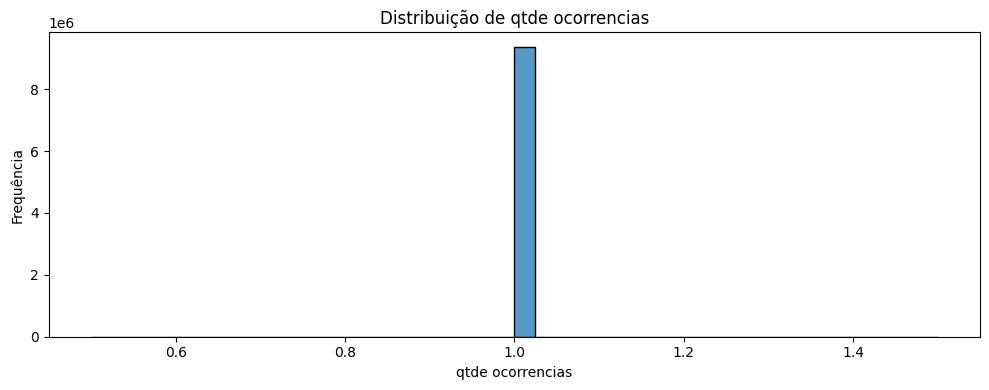

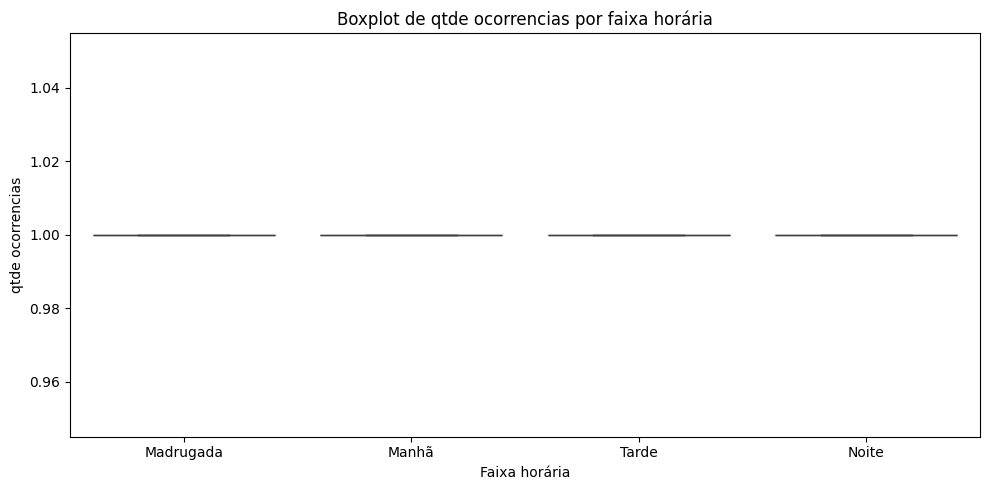

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

# Análise de distribuição da variável de volume.
plt.figure(figsize=(10, 4))
sns.histplot(dataset_combinado["qtde ocorrencias"].dropna(), bins=40, kde=False)
plt.title("Distribuição de qtde ocorrencias")
plt.xlabel("qtde ocorrencias")
plt.ylabel("Frequência")
plt.tight_layout()
plt.show()

# Boxplot por faixa horária para avaliar dispersão.
base_box = dataset_combinado[["faixa_horaria", "qtde ocorrencias"]].dropna().copy()
ordem_faixa_plot = ["Madrugada", "Manhã", "Tarde", "Noite", "Não Informado"]
ordem_faixa_plot = [x for x in ordem_faixa_plot if x in base_box["faixa_horaria"].astype(str).unique()]

plt.figure(figsize=(10, 5))
sns.boxplot(
    data=base_box,
    x="faixa_horaria",
    y="qtde ocorrencias",
    order=ordem_faixa_plot,
    showfliers=False
)
plt.title("Boxplot de qtde ocorrencias por faixa horária")
plt.xlabel("Faixa horária")
plt.ylabel("qtde ocorrencias")
plt.tight_layout()
plt.show()

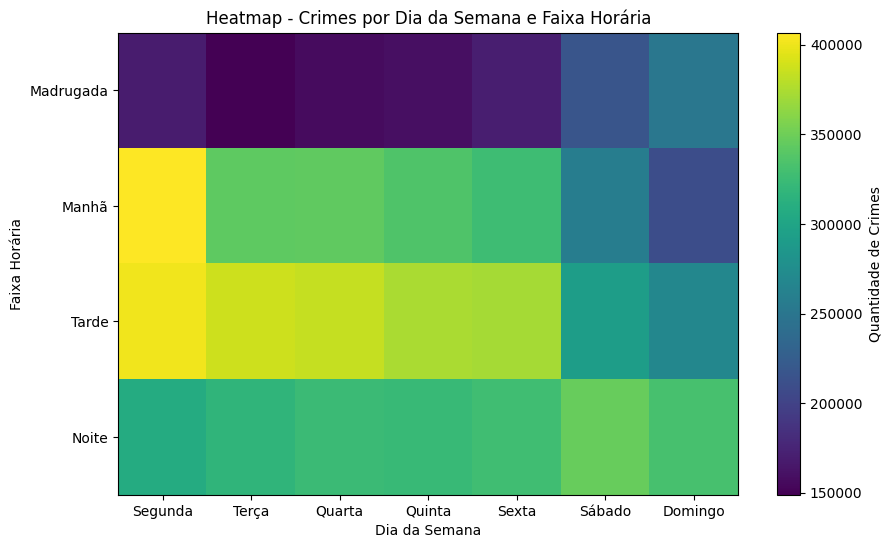


Total de crimes por dia da semana:
dia_semana_fato
Segunda    1284118.0
Quarta     1209818.0
Terça      1197008.0
Sexta      1196715.0
Quinta     1191618.0
Sábado     1114105.0
Domingo    1060432.0
dtype: float64

Dias que tiveram crimes:
dia_semana_fato
Segunda    1284118.0
Terça      1197008.0
Quarta     1209818.0
Quinta     1191618.0
Sexta      1196715.0
Sábado     1114105.0
Domingo    1060432.0
dtype: float64

Dia com mais crimes: Segunda (1284118.0)


In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Define a ordem de dias e faixas horárias.
ordem_faixa = ['Madrugada', 'Manhã', 'Tarde', 'Noite']
ordem_dia = [1, 2, 3, 4, 5, 6, 7]

mapa_dias = {
    1: 'Segunda',
    2: 'Terça',
    3: 'Quarta',
    4: 'Quinta',
    5: 'Sexta',
    6: 'Sábado',
    7: 'Domingo'
}

# Cria a matriz de ocorrências por dia e faixa horária.
tabela = (
    dataset_combinado
    .groupby(['dia_semana_fato', 'faixa_horaria'])['qtde ocorrencias']
    .sum()
    .unstack(fill_value=0)
)

# Reordena linhas e colunas conforme a ordem definida.
tabela = tabela.reindex(index=ordem_dia, columns=ordem_faixa)

# Substitui o número do dia pelo nome correspondente.
tabela.index = tabela.index.map(mapa_dias)

# Transpõe a matriz para deixar as faixas no eixo Y.
tabela = tabela.T

# Gera o heatmap de ocorrências.
plt.figure(figsize=(10,6))
plt.imshow(tabela, aspect='auto')

plt.xticks(np.arange(len(tabela.columns)), tabela.columns)
plt.yticks(np.arange(len(tabela.index)), tabela.index)

plt.colorbar(label='Quantidade de Crimes')
plt.title('Heatmap - Crimes por Dia da Semana e Faixa Horária')
plt.xlabel('Dia da Semana')
plt.ylabel('Faixa Horária')

plt.show()

# Resume os totais por dia da semana.

total_por_dia = tabela.sum(axis=0)

print('\nTotal de crimes por dia da semana:')
print(total_por_dia.sort_values(ascending=False))

print('\nDias que tiveram crimes:')
print(total_por_dia[total_por_dia > 0])

dia_mais_crime = total_por_dia.idxmax()
valor_maximo = total_por_dia.max()

print(f'\nDia com mais crimes: {dia_mais_crime} ({valor_maximo})')


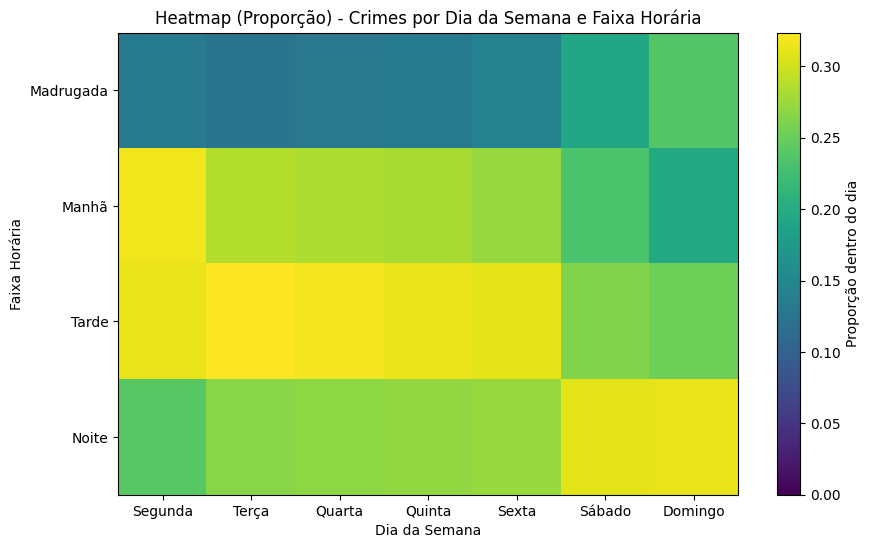

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

ordem_faixa = ['Madrugada', 'Manhã', 'Tarde', 'Noite']
ordem_dia = [1, 2, 3, 4, 5, 6, 7]

mapa_dias = {1:'Segunda',2:'Terça',3:'Quarta',4:'Quinta',5:'Sexta',6:'Sábado',7:'Domingo'}

tabela = (
    dataset_combinado
    .groupby(['dia_semana_fato','faixa_horaria'])['qtde ocorrencias']
    .sum()
    .unstack(fill_value=0)
).reindex(index=ordem_dia, columns=ordem_faixa)

# Normaliza as ocorrências dentro de cada dia.
tabela.index = tabela.index.map(mapa_dias)
tabela = tabela.T

tabela_prop = tabela.div(tabela.sum(axis=0), axis=1)  # divide cada coluna pelo total do dia

plt.figure(figsize=(10,6))
plt.imshow(tabela_prop, aspect='auto', vmin=0, vmax=tabela_prop.to_numpy().max())

plt.xticks(np.arange(len(tabela_prop.columns)), tabela_prop.columns)
plt.yticks(np.arange(len(tabela_prop.index)), tabela_prop.index)

plt.colorbar(label='Proporção dentro do dia')
plt.title('Heatmap (Proporção) - Crimes por Dia da Semana e Faixa Horária')
plt.xlabel('Dia da Semana')
plt.ylabel('Faixa Horária')
plt.show()

In [12]:
import re

padrao_violento = re.compile(
    r"HOMIC|ROUBO|LATROCIN|ESTUPRO|LES[AÃ]O|SEQUESTRO|EXTORS",
    re.IGNORECASE
)

dataset_combinado["crime_violento"] = (
    dataset_combinado["natureza_principal_completa"]
    .fillna("")
    .apply(lambda x: 1 if padrao_violento.search(x) else 0)
)
p_violento = (
    (dataset_combinado["crime_violento"] *
     dataset_combinado["qtde ocorrencias"]).sum()
    / dataset_combinado["qtde ocorrencias"].sum()
)

print("Proporção geral ponderada:", p_violento)

Proporção geral ponderada: 0.2858838770332108


In [13]:
dataset_combinado["usa_arma_fogo"] = (
    dataset_combinado["descricao_longa_meio_utilizado"]
    .fillna("")
    .str.upper()
    .str.contains("ARMA DE FOGO", na=False)
    .astype(int)
)

p_arma_fogo = (
    (dataset_combinado["usa_arma_fogo"] * dataset_combinado["qtde ocorrencias"]).sum()
    / dataset_combinado["qtde ocorrencias"].sum()
)

print("Proporção geral (ponderada) de ocorrências com arma de fogo:", p_arma_fogo)

arma_por_faixa = (
    dataset_combinado
    .groupby("faixa_horaria")
    .apply(lambda x:
        (x["usa_arma_fogo"] * x["qtde ocorrencias"]).sum()
        / x["qtde ocorrencias"].sum()
    )
    .sort_values(ascending=False)
)

print(arma_por_faixa)

arma_por_risp = (
    dataset_combinado
    .groupby("risp")
    .apply(lambda x:
        (x["usa_arma_fogo"] * x["qtde ocorrencias"]).sum()
        / x["qtde ocorrencias"].sum()
    )
    .sort_values(ascending=False)
)

print(arma_por_risp)

arma_risp_faixa = dataset_combinado.groupby(
    ["risp", "faixa_horaria"]
).apply(lambda x:
    (x["usa_arma_fogo"] * x["qtde ocorrencias"]).sum()
    / x["qtde ocorrencias"].sum()
).unstack()

print(arma_risp_faixa)

tabela_arma = dataset_combinado.groupby(
    ["faixa_horaria"]
).apply(lambda x:
    pd.Series({
        "arma": (x["usa_arma_fogo"] * x["qtde ocorrencias"]).sum(),
        "sem_arma": ((1 - x["usa_arma_fogo"]) * x["qtde ocorrencias"]).sum()
    })
)

from scipy.stats import chi2_contingency

chi2, p, _, _ = chi2_contingency(tabela_arma)
print("p-valor ponderado:", p)

Proporção geral (ponderada) de ocorrências com arma de fogo: 0.002689689041462455
faixa_horaria
Noite        0.004686
Madrugada    0.002202
Tarde        0.002016
Manhã        0.001473
dtype: float64
risp
RISP 2 - CONTAGEM            0.005491
RISP 19 - SETE LAGOAS        0.003508
RISP 1 - BH                  0.003237
RISP 6 - LAVRAS              0.003202
RISP 3 - VESPASIANO          0.003044
RISP 7 - DIVINÓPOLIS         0.002326
RISP 18 - POÇOS DE CALDAS    0.002145
RISP 10 - PATOS DE MINAS     0.002082
RISP 16 - UNAÍ               0.002029
RISP 9 - UBERLÂNDIA          0.001999
RISP 11 - MONTES CLAROS      0.001970
RISP 12 - IPATINGA           0.001910
RISP 5 - UBERABA             0.001839
RISP 17 - POUSO ALEGRE       0.001718
RISP 14 - CURVELO            0.001704
RISP 8 - GOV. VALADARES      0.001702
RISP 4 - JUIZ DE FORA        0.001521
RISP 15 - TEÓFILO OTONI      0.001260
RISP 13 - BARBACENA          0.001116
dtype: float64
faixa_horaria              Madrugada     Manhã     Noite   

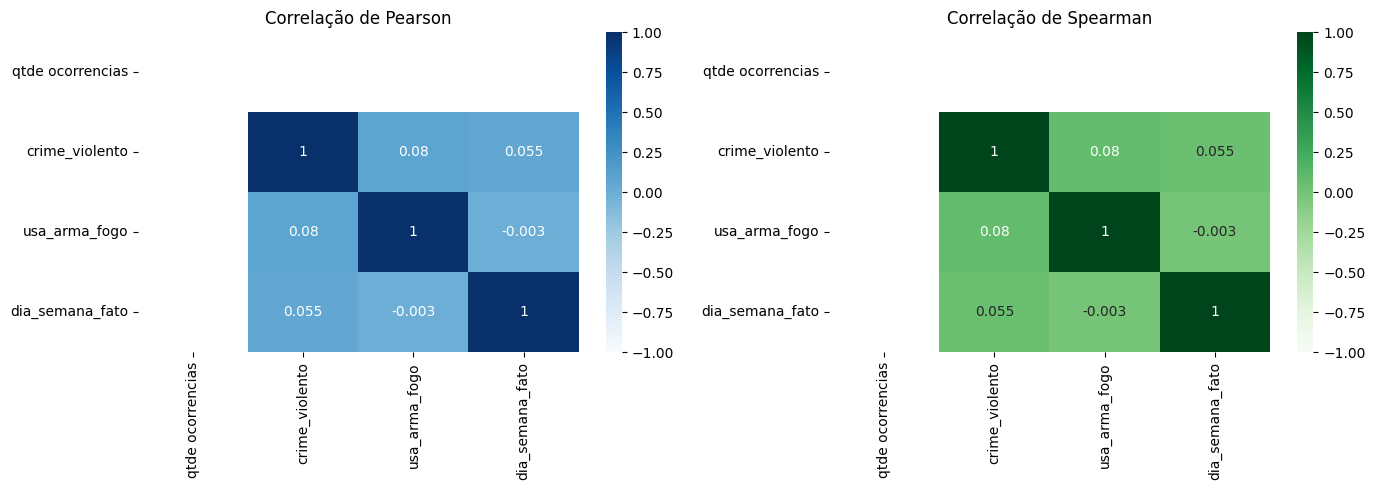

In [14]:
# Matriz de correlação para variáveis numéricas.
vars_numericas = [
    "qtde ocorrencias",
    "crime_violento",
    "usa_arma_fogo",
    "dia_semana_fato"
]
vars_numericas = [v for v in vars_numericas if v in dataset_combinado.columns]

if len(vars_numericas) >= 2:
    base_corr = dataset_combinado[vars_numericas].apply(pd.to_numeric, errors="coerce")

    corr_pearson = base_corr.corr(method="pearson")
    corr_spearman = base_corr.corr(method="spearman")

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    sns.heatmap(corr_pearson, annot=True, cmap="Blues", vmin=-1, vmax=1, ax=axes[0])
    axes[0].set_title("Correlação de Pearson")

    sns.heatmap(corr_spearman, annot=True, cmap="Greens", vmin=-1, vmax=1, ax=axes[1])
    axes[1].set_title("Correlação de Spearman")

    plt.tight_layout()
    plt.show()
else:
    print("Não há variáveis numéricas suficientes para montar a correlação.")

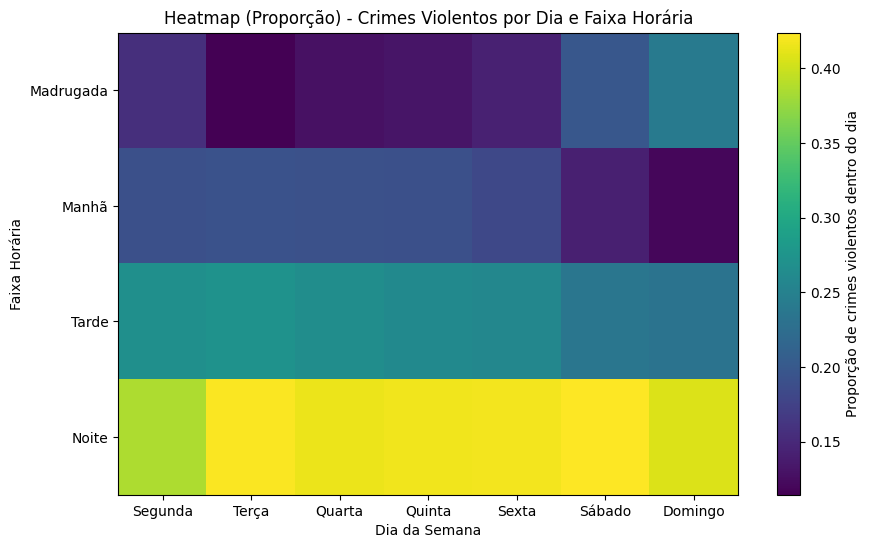

In [15]:
import numpy as np
import matplotlib.pyplot as plt

# Matriz de crimes violentos (ponderado)
tabela_viol = (
    dataset_combinado
    .groupby(["dia_semana_fato", "faixa_horaria"])["qtde ocorrencias"]
    .apply(lambda s: 0)  # placeholder só pra manter estrutura (não use)
)

tabela_viol = (
    dataset_combinado
    .groupby(["dia_semana_fato", "faixa_horaria"])
    .apply(lambda x: (x["crime_violento"] * x["qtde ocorrencias"]).sum())
    .unstack(fill_value=0)
    .reindex(index=ordem_dia, columns=ordem_faixa)
)

# Ajustar nomes e orientar (faixas no eixo Y)
tabela_viol.index = tabela_viol.index.map(mapa_dias)
tabela_viol = tabela_viol.T

# Proporção dentro de cada dia (normalização por coluna)
tabela_viol_prop = tabela_viol.div(tabela_viol.sum(axis=0), axis=1)

# Plot do heatmap
plt.figure(figsize=(10, 6))
plt.imshow(tabela_viol_prop, aspect="auto")

plt.xticks(np.arange(len(tabela_viol_prop.columns)), tabela_viol_prop.columns)
plt.yticks(np.arange(len(tabela_viol_prop.index)), tabela_viol_prop.index)

plt.colorbar(label="Proporção de crimes violentos dentro do dia")
plt.title("Heatmap (Proporção) - Crimes Violentos por Dia e Faixa Horária")
plt.xlabel("Dia da Semana")
plt.ylabel("Faixa Horária")
plt.show()

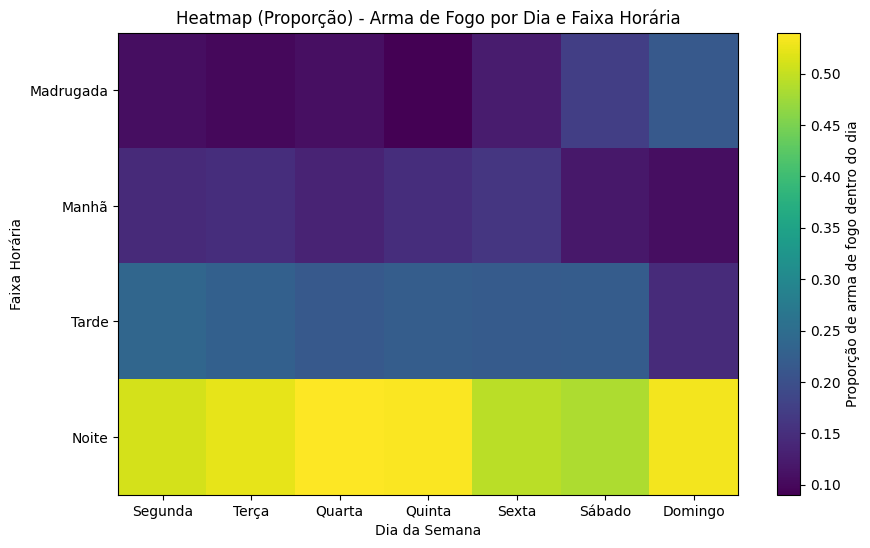

In [16]:
tabela_arma = (
    dataset_combinado
    .groupby(['dia_semana_fato','faixa_horaria'])
    .apply(lambda x: (x['usa_arma_fogo'] * x['qtde ocorrencias']).sum())
    .unstack(fill_value=0)
).reindex(index=ordem_dia, columns=ordem_faixa)

tabela_arma.index = tabela_arma.index.map(mapa_dias)
tabela_arma = tabela_arma.T

tabela_arma_prop = tabela_arma.div(tabela_arma.sum(axis=0), axis=1)

plt.figure(figsize=(10,6))
plt.imshow(tabela_arma_prop, aspect='auto')

plt.xticks(np.arange(len(tabela_arma_prop.columns)), tabela_arma_prop.columns)
plt.yticks(np.arange(len(tabela_arma_prop.index)), tabela_arma_prop.index)

plt.colorbar(label='Proporção de arma de fogo dentro do dia')
plt.title('Heatmap (Proporção) - Arma de Fogo por Dia e Faixa Horária')
plt.xlabel('Dia da Semana')
plt.ylabel('Faixa Horária')
plt.show()

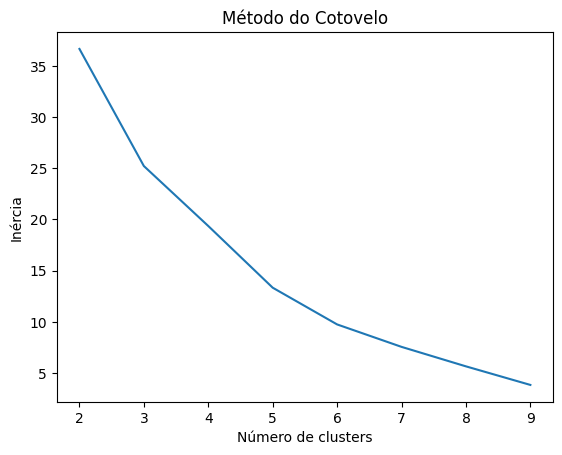

In [17]:
df_cluster = (
    dataset_combinado
    .groupby(["natureza_principal_completa", "faixa_horaria"])["qtde ocorrencias"]
    .sum()
    .unstack(fill_value=0)
)

# Remove tipos de crime muito raros
freq_crimes = df_cluster.sum(axis=1)
df_cluster = df_cluster.loc[freq_crimes >= 100]

# Converte as contagens para perfil proporcional por tipo de crime
df_cluster = df_cluster.div(df_cluster.sum(axis=1), axis=0)

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Padroniza os dados para a clusterização
scaler = StandardScaler()
X = scaler.fit_transform(df_cluster)

# Método do cotovelo
inercia = []

for k in range(2, 10):
    modelo = KMeans(n_clusters=k, random_state=42, n_init=10)
    modelo.fit(X)
    inercia.append(modelo.inertia_)

plt.plot(range(2, 10), inercia)
plt.xlabel("Número de clusters")
plt.ylabel("Inércia")
plt.title("Método do Cotovelo")
plt.show()

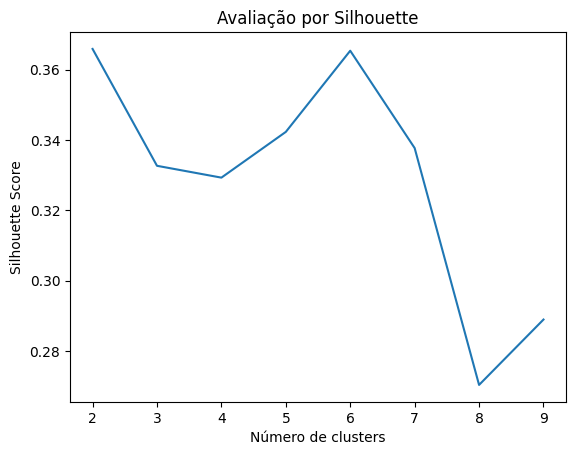

In [18]:
from sklearn.metrics import silhouette_score

sil_scores = []

for k in range(2, 10):
    modelo = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = modelo.fit_predict(X)
    sil_scores.append(silhouette_score(X, labels))

plt.plot(range(2, 10), sil_scores)
plt.xlabel("Número de clusters")
plt.ylabel("Silhouette Score")
plt.title("Avaliação por Silhouette")
plt.show()

In [19]:
K_FINAL = 3

kmeans = KMeans(n_clusters=K_FINAL, random_state=42, n_init=10)
labels = kmeans.fit_predict(X)

df_cluster_final = df_cluster.copy()
df_cluster_final["cluster"] = labels

df_cluster_final.head()

faixa_horaria,Madrugada,Manhã,Noite,Tarde,cluster
natureza_principal_completa,,,,,
ESTUPRO CONSUMADO,0.306415,0.190245,0.274339,0.229001,0
ESTUPRO DE VULNERAVEL CONSUMADO,0.213183,0.208984,0.249445,0.328388,0
ESTUPRO DE VULNERAVEL TENTADO,0.207787,0.196608,0.264842,0.330763,0
ESTUPRO TENTADO,0.250323,0.202755,0.301980,0.244942,0
EXTORSAO CONSUMADO,0.118294,0.244981,0.292495,0.344230,1


   componente  variancia_explicada  variancia_acumulada
0           1         6.216542e-01             0.621654
1           2         2.311480e-01             0.852802
2           3         1.471978e-01             1.000000
3           4         1.810447e-32             1.000000


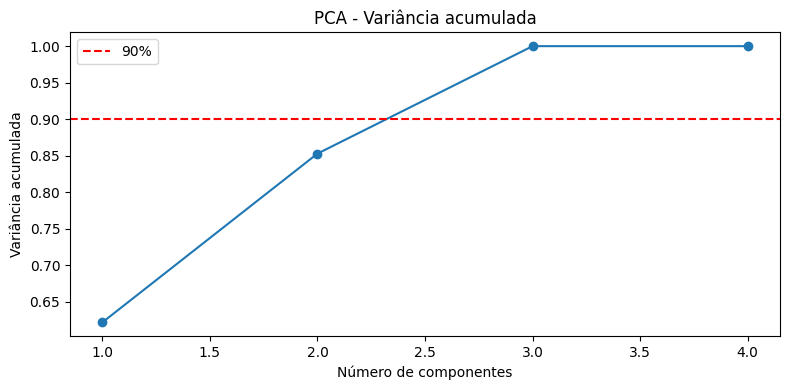

In [20]:
from sklearn.decomposition import PCA

# Aplica PCA nos dados padronizados para avaliar variância explicada.
pca = PCA()
pca.fit(X)

variancia_exp = pca.explained_variance_ratio_
variancia_acum = variancia_exp.cumsum()

pca_df = pd.DataFrame({
    "componente": range(1, len(variancia_exp) + 1),
    "variancia_explicada": variancia_exp,
    "variancia_acumulada": variancia_acum
})
print(pca_df)

plt.figure(figsize=(8, 4))
plt.plot(pca_df["componente"], pca_df["variancia_acumulada"], marker="o")
plt.axhline(0.90, color="red", linestyle="--", label="90%")
plt.title("PCA - Variância acumulada")
plt.xlabel("Número de componentes")
plt.ylabel("Variância acumulada")
plt.legend()
plt.tight_layout()
plt.show()

In [21]:
from sklearn.metrics import silhouette_score

for k in range(2,8):
    modelo = KMeans(n_clusters=k, random_state=42)
    labels = modelo.fit_predict(X)
    print(k, silhouette_score(X, labels))

2 0.35961040087703067
3 0.32011587519675133
4 0.31517115341882457
5 0.26505015092106365
6 0.2634644296908024
7 0.33770493128383616


In [22]:
from sklearn.metrics import davies_bouldin_score, calinski_harabasz_score

# Compara métricas de qualidade para diferentes valores de k.
ks = range(2, 8)
metricas_cluster = []

for k in ks:
    modelo = KMeans(n_clusters=k, random_state=42, n_init="auto")
    labels_k = modelo.fit_predict(X)
    metricas_cluster.append({
        "k": k,
        "silhouette": silhouette_score(X, labels_k),
        "davies_bouldin": davies_bouldin_score(X, labels_k),
        "calinski_harabasz": calinski_harabasz_score(X, labels_k)
    })

metricas_cluster_df = pd.DataFrame(metricas_cluster)
print(metricas_cluster_df)

   k  silhouette  davies_bouldin  calinski_harabasz
0  2    0.359610        0.416712           4.717501
1  3    0.320116        0.834138           9.667368
2  4    0.315171        0.737442          10.738193
3  5    0.265050        0.857025          10.373227
4  6    0.263464        0.745788           9.680127
5  7    0.337705        0.536909          13.332339


In [23]:
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

# Avalia estabilidade do K-Means com múltiplas sementes.
seeds = [0, 1, 2, 42, 100]
k_estabilidade = 3
labels_por_seed = {}

for seed in seeds:
    modelo = KMeans(n_clusters=k_estabilidade, random_state=seed, n_init="auto")
    labels_por_seed[seed] = modelo.fit_predict(X)

pares = []
for i, s1 in enumerate(seeds):
    for s2 in seeds[i+1:]:
        ari = adjusted_rand_score(labels_por_seed[s1], labels_por_seed[s2])
        nmi = normalized_mutual_info_score(labels_por_seed[s1], labels_por_seed[s2])
        pares.append({"seed_1": s1, "seed_2": s2, "ARI": ari, "NMI": nmi})

estabilidade_df = pd.DataFrame(pares)
print(estabilidade_df)
print("ARI médio:", estabilidade_df["ARI"].mean())
print("NMI médio:", estabilidade_df["NMI"].mean())

   seed_1  seed_2       ARI       NMI
0       0       1  0.645833  0.709570
1       0       2  0.306796  0.441100
2       0      42  0.302239  0.479340
3       0     100  0.446360  0.584147
4       1       2  0.339806  0.452561
5       1      42  0.365672  0.511638
6       1     100  0.544061  0.713163
7       2      42  0.722323  0.765415
8       2     100  0.592251  0.717276
9      42     100  0.693141  0.754765
ARI médio: 0.49584819445156647
NMI médio: 0.6128975256336698


In [24]:
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
import numpy as np

db = DBSCAN(eps=1.5, min_samples=10)
labels_db = db.fit_predict(X)

mask = labels_db != -1

print("DBSCAN")
print("Número de clusters:", len(set(labels_db)) - (1 if -1 in labels_db else 0))
print("Número de ruídos:", np.sum(labels_db == -1))

if len(set(labels_db[mask])) > 1:
    print("Silhouette:", silhouette_score(X[mask], labels_db[mask]))
    print("Davies-Bouldin:", davies_bouldin_score(X[mask], labels_db[mask]))
    print("Calinski-Harabasz:", calinski_harabasz_score(X[mask], labels_db[mask]))
else:
    print("DBSCAN não formou clusters suficientes para cálculo confiável das métricas.")

DBSCAN
Número de clusters: 0
Número de ruídos: 17
DBSCAN não formou clusters suficientes para cálculo confiável das métricas.


In [25]:
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
import pandas as pd
import numpy as np

resultados_cluster = []

# K-MEANS
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
labels_km = kmeans.fit_predict(X)

resultados_cluster.append({
    "metodo": "K-Means",
    "n_clusters": len(set(labels_km)),
    "silhouette": silhouette_score(X, labels_km),
    "davies_bouldin": davies_bouldin_score(X, labels_km),
    "calinski_harabasz": calinski_harabasz_score(X, labels_km)
})

# HIERÁRQUICO
agl = AgglomerativeClustering(n_clusters=3, linkage="ward")
labels_agl = agl.fit_predict(X)

resultados_cluster.append({
    "metodo": "Hierárquico",
    "n_clusters": len(set(labels_agl)),
    "silhouette": silhouette_score(X, labels_agl),
    "davies_bouldin": davies_bouldin_score(X, labels_agl),
    "calinski_harabasz": calinski_harabasz_score(X, labels_agl)
})

# DBSCAN
db = DBSCAN(eps=1.5, min_samples=10)
labels_db = db.fit_predict(X)

mask = labels_db != -1

if len(set(labels_db[mask])) > 1:
    resultados_cluster.append({
        "metodo": "DBSCAN",
        "n_clusters": len(set(labels_db)) - (1 if -1 in labels_db else 0),
        "silhouette": silhouette_score(X[mask], labels_db[mask]),
        "davies_bouldin": davies_bouldin_score(X[mask], labels_db[mask]),
        "calinski_harabasz": calinski_harabasz_score(X[mask], labels_db[mask])
    })
else:
    resultados_cluster.append({
        "metodo": "DBSCAN",
        "n_clusters": len(set(labels_db)) - (1 if -1 in labels_db else 0),
        "silhouette": np.nan,
        "davies_bouldin": np.nan,
        "calinski_harabasz": np.nan
    })

comparacao_clusters = pd.DataFrame(resultados_cluster)

comparacao_clusters

,metodo,n_clusters,silhouette,davies_bouldin,calinski_harabasz
0,K-Means,3,0.332665,0.972759,11.871378
1,Hierárquico,3,0.310569,1.044679,10.239894
2,DBSCAN,0,NaN,NaN,NaN


In [35]:
crimes_por_cluster = (
    df_cluster_final.reset_index()
    .groupby("cluster")["natureza_principal_completa"]
    .apply(list)
)

for cluster, crimes in crimes_por_cluster.items():
    print(f"\nCluster {cluster}")
    for crime in crimes[:20]:
        print("-", crime)


Cluster 0
- ESTUPRO CONSUMADO
- ESTUPRO DE VULNERAVEL CONSUMADO
- ESTUPRO DE VULNERAVEL TENTADO
- ESTUPRO TENTADO
- FEMINICIDIO CONSUMADO
- FEMINICIDIO TENTADO
- SEQUESTRO E CARCERE PRIVADO CONSUMADO

Cluster 1
- EXTORSAO CONSUMADO
- EXTORSAO MEDIANTE SEQUESTRO CONSUMADO
- EXTORSAO TENTADO
- FURTO CONSUMADO
- SEQUESTRO E CARCERE PRIVADO TENTADO

Cluster 2
- HOMICIDIO CONSUMADO
- HOMICIDIO TENTADO
- LESAO CORPORAL CONSUMADO
- ROUBO CONSUMADO
- ROUBO TENTADO


In [36]:
from numpy.linalg import norm
import numpy as np

centroids = kmeans.cluster_centers_
dist = np.vstack([norm(X - centroids[c], axis=1) for c in range(K_FINAL)]).T

df_cluster_final["dist_to_centroid"] = dist[np.arange(len(labels)), labels]

top_representativos = (
    df_cluster_final.reset_index()
    .sort_values(["cluster", "dist_to_centroid"])
    .groupby("cluster")
    .head(10)[["cluster", "natureza_principal_completa", "dist_to_centroid"]]
)

print(top_representativos)

faixa_horaria  cluster            natureza_principal_completa  \
15                   0  SEQUESTRO E CARCERE PRIVADO CONSUMADO   
3                    0                        ESTUPRO TENTADO   
8                    0                    FEMINICIDIO TENTADO   
1                    0        ESTUPRO DE VULNERAVEL CONSUMADO   
2                    0          ESTUPRO DE VULNERAVEL TENTADO   
0                    0                      ESTUPRO CONSUMADO   
7                    0                  FEMINICIDIO CONSUMADO   
4                    1                     EXTORSAO CONSUMADO   
9                    1                        FURTO CONSUMADO   
5                    1  EXTORSAO MEDIANTE SEQUESTRO CONSUMADO   
16                   1    SEQUESTRO E CARCERE PRIVADO TENTADO   
6                    1                       EXTORSAO TENTADO   
14                   2                          ROUBO TENTADO   
13                   2                        ROUBO CONSUMADO   
12                   2   

In [38]:
labels_cluster = {}

for c in sorted(top_representativos["cluster"].unique()):
    crimes = top_representativos[top_representativos["cluster"] == c]["natureza_principal_completa"]
    labels_cluster[c] = "\n".join(crimes)

Silhouette final (K=3): 0.3327

Perfil médio dos clusters (proporção por faixa horária):
faixa_horaria  Madrugada     Manhã     Noite     Tarde
cluster                                               
0               0.224675  0.231661  0.276256  0.267408
1               0.125570  0.270956  0.251283  0.352191
2               0.178858  0.164127  0.420768  0.236247


<Figure size 1000x500 with 0 Axes>

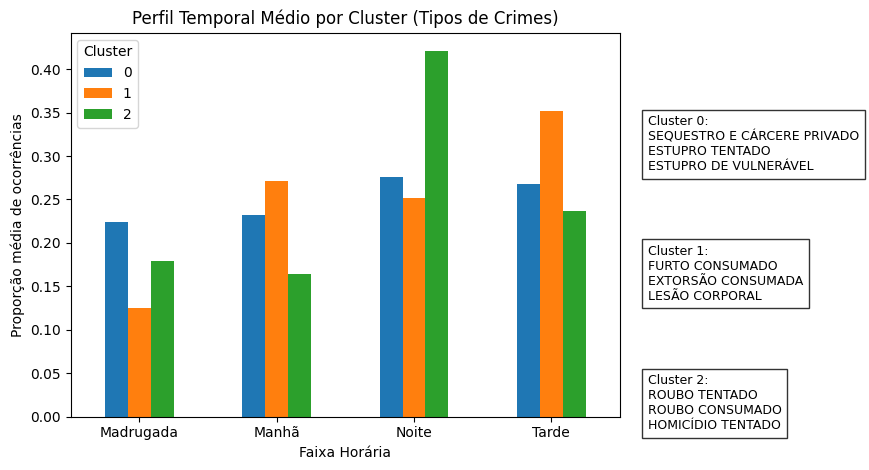


Quantidade de tipos de crime por cluster:
cluster
0    7
1    5
2    5
Name: count, dtype: int64

Exemplo de tipos de crime (20 primeiros) por cluster:
cluster
0    [ESTUPRO CONSUMADO, ESTUPRO DE VULNERAVEL CONS...
1    [EXTORSAO CONSUMADO, EXTORSAO MEDIANTE SEQUEST...
2    [HOMICIDIO CONSUMADO, HOMICIDIO TENTADO, LESAO...
Name: natureza_principal_completa, dtype: object

Resumo dos clusters:
         qtd_tipos_crime                                           exemplos
cluster                                                                    
0                      7  [ESTUPRO CONSUMADO, ESTUPRO DE VULNERAVEL CONS...
1                      5  [EXTORSAO CONSUMADO, EXTORSAO MEDIANTE SEQUEST...
2                      5  [HOMICIDIO CONSUMADO, HOMICIDIO TENTADO, LESAO...

Top 10 tipos de crimes mais representativos por cluster:
faixa_horaria  cluster            natureza_principal_completa  \
15                   0  SEQUESTRO E CARCERE PRIVADO CONSUMADO   
3                    0             

In [42]:
# Fluxo final para análise dos padrões contextuais dos tipos de crimes
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Configuração final do modelo
K_FINAL = 3
SEED = 42

# Remove valores inválidos
df_cluster = df_cluster.replace([np.inf, -np.inf], np.nan).dropna(axis=0)

# Padronização
scaler = StandardScaler()
X = scaler.fit_transform(df_cluster)

# Treina o modelo final
kmeans = KMeans(n_clusters=K_FINAL, random_state=SEED, n_init=10)
labels = kmeans.fit_predict(X)

# Anexa os rótulos
df_cluster_final = df_cluster.copy()
df_cluster_final["cluster"] = labels

# Avaliação final
sil = silhouette_score(X, labels)
print(f"Silhouette final (K={K_FINAL}): {sil:.4f}")

# Perfil médio dos clusters
perfil_cluster = df_cluster_final.groupby("cluster").mean(numeric_only=True)

print("\nPerfil médio dos clusters (proporção por faixa horária):")
print(perfil_cluster)

# Visualização do perfil dos clusters
plt.figure(figsize=(10, 5))
perfil_cluster.T.plot(kind="bar")

plt.title("Perfil Temporal Médio por Cluster (Tipos de Crimes)")
plt.xlabel("Faixa Horária")
plt.ylabel("Proporção média de ocorrências")
plt.xticks(rotation=0)
plt.legend(title="Cluster")

plt.figtext(
    1.02, 0.75,
    "Cluster 0:\nSEQUESTRO E CÁRCERE PRIVADO\nESTUPRO TENTADO\nESTUPRO DE VULNERÁVEL",
    ha="left", va="top", fontsize=9,
    bbox=dict(facecolor="white", alpha=0.8)
)

plt.figtext(
    1.02, 0.48,
    "Cluster 1:\nFURTO CONSUMADO\nEXTORSÃO CONSUMADA\nLESÃO CORPORAL",
    ha="left", va="top", fontsize=9,
    bbox=dict(facecolor="white", alpha=0.8)
)

plt.figtext(
    1.02, 0.21,
    "Cluster 2:\nROUBO TENTADO\nROUBO CONSUMADO\nHOMICÍDIO TENTADO",
    ha="left", va="top", fontsize=9,
    bbox=dict(facecolor="white", alpha=0.8)
)

plt.tight_layout()
plt.show()

# Quantidade de tipos de crimes por cluster
print("\nQuantidade de tipos de crime por cluster:")
print(df_cluster_final["cluster"].value_counts().sort_index())

# Lista resumida de crimes por cluster
crimes_por_cluster = (
    df_cluster_final.reset_index()
    .groupby("cluster")["natureza_principal_completa"]
    .apply(lambda s: list(s)[:20])
)

print("\nExemplo de tipos de crime (20 primeiros) por cluster:")
print(crimes_por_cluster)

# Resumo mais organizado
resumo_clusters = (
    df_cluster_final.reset_index()
    .groupby("cluster")["natureza_principal_completa"]
    .agg(
        qtd_tipos_crime="count",
        exemplos=lambda s: list(s)[:20]
    )
)

print("\nResumo dos clusters:")
print(resumo_clusters)

# Crimes mais representativos de cada cluster
from numpy.linalg import norm

centroids = kmeans.cluster_centers_
dist = np.vstack([norm(X - centroids[c], axis=1) for c in range(K_FINAL)]).T

df_cluster_final["dist_to_centroid"] = dist[np.arange(len(labels)), labels]

top_representativos = (
    df_cluster_final.reset_index()
    .sort_values(["cluster", "dist_to_centroid"])
    .groupby("cluster")
    .head(10)[["cluster", "natureza_principal_completa", "dist_to_centroid"]]
)

print("\nTop 10 tipos de crimes mais representativos por cluster:")
print(top_representativos)

# Exporta resultado final
df_cluster_final.reset_index().to_csv("clusters_tipos_crime.csv", index=False)

print("\nArquivo gerado: clusters_tipos_crime.csv")

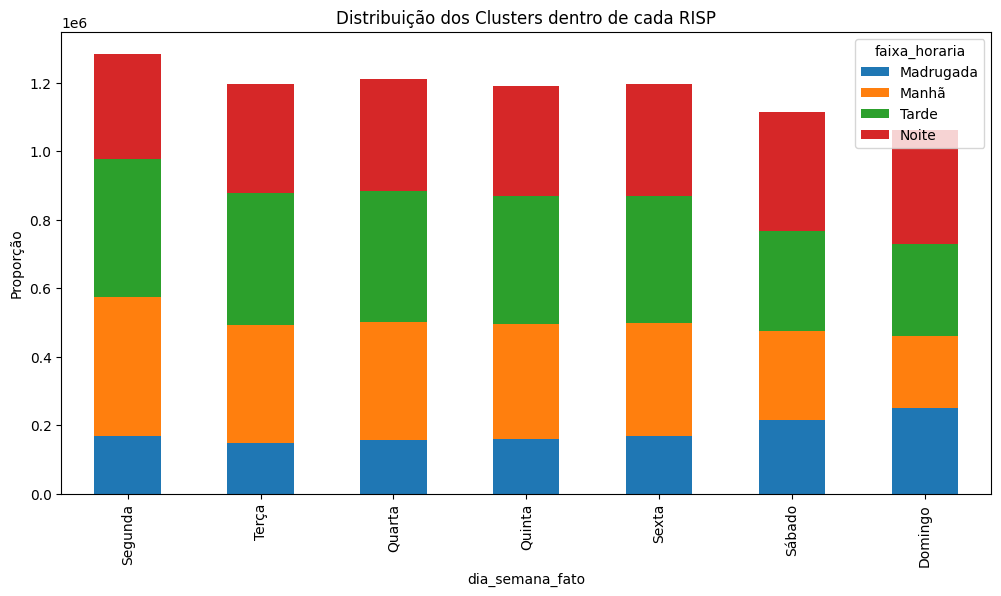

In [27]:
tabela.T.plot(kind="bar", stacked=True, figsize=(12,6))
plt.title("Distribuição dos Clusters dentro de cada RISP")
plt.ylabel("Proporção")
plt.show()

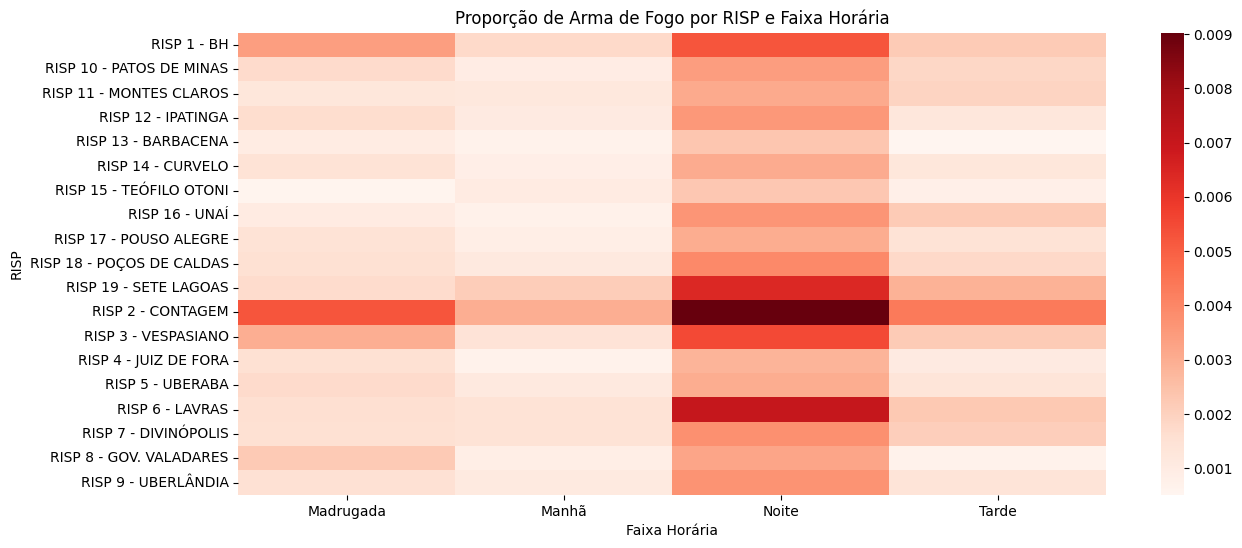

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))
sns.heatmap(arma_risp_faixa, cmap="Reds", annot=False)
plt.title("Proporção de Arma de Fogo por RISP e Faixa Horária")
plt.ylabel("RISP")
plt.xlabel("Faixa Horária")
plt.show()

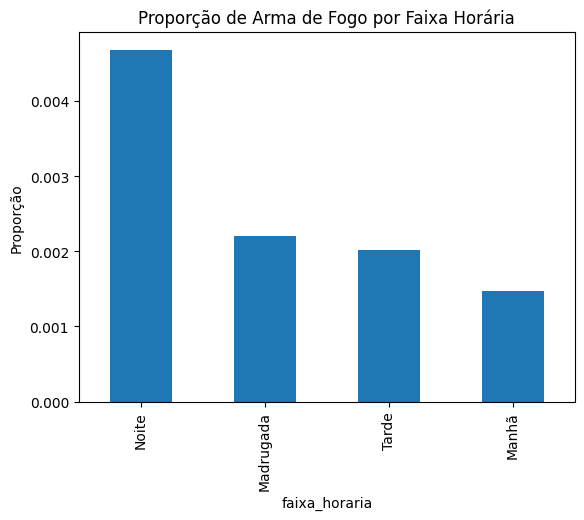

In [29]:
arma_por_faixa.plot(kind="bar")
plt.title("Proporção de Arma de Fogo por Faixa Horária")
plt.ylabel("Proporção")
plt.show()

In [30]:
from scipy.stats import chi2_contingency
import numpy as np

tabela = pd.pivot_table(
    dataset_combinado[dataset_combinado["descricao local imediato"].notna()],
    values="qtde ocorrencias",
    index="crime_violento",
    columns="descricao local imediato",
    aggfunc="sum",
    fill_value=0
)

chi2, p, dof, expected = chi2_contingency(tabela)

print("Qui-quadrado:", chi2)
print("p-value:", p)

n = tabela.values.sum()
k = min(tabela.shape) - 1
cramers_v = np.sqrt(chi2 / (n * k))

print("Cramér's V:", cramers_v)

Qui-quadrado: 635668.3859635122
p-value: 0.0
Cramér's V: 0.2712567965789548


In [31]:
dataset_combinado.groupby("descricao local imediato")["qtde ocorrencias"].sum().sort_values(ascending=False).head(20)

descricao local imediato
VIA DE ACESSO PUBLICA                                        3874603.0
CASA                                                         1630547.0
OUTROS - ESTABELECIMENTOS COMERCIAIS / SERVICOS               307305.0
BAR / LANCHONETE / RESTAURANTE / SIMILAR                      265489.0
FAZENDA                                                       191976.0
MERCEARIA / SACOLAO / SUPERMERCADO                            171169.0
SITIO                                                         167498.0
LOJA DIVERSA                                                  148684.0
DROGARIA / FARMACIA                                           110775.0
VIA DE ACESSO PARTICULAR/PRIVADA                               96752.0
APARTAMENTO                                                    95025.0
POSTO DE COMBUSTIVEL                                           87084.0
ONIBUS                                                         83630.0
AUTOMOVEL                                           

In [32]:
# Resumo final com os principais indicadores.
resumo_final = {}

if "p_arma_fogo" in globals():
    resumo_final["p_arma_fogo"] = p_arma_fogo
if "p_violento" in globals():
    resumo_final["p_violento"] = p_violento
if "K_FINAL" in globals():
    resumo_final["K_FINAL"] = K_FINAL
if "sil" in globals():
    resumo_final["silhouette_final"] = sil
if "p" in globals():
    resumo_final["ultimo_p_valor_calculado"] = p

import pandas as pd
resumo_df = pd.DataFrame(
    [{"indicador": k, "valor": v} for k, v in resumo_final.items()]
).sort_values("indicador")

print("Resumo dos indicadores disponíveis no ambiente:")
display(resumo_df if not resumo_df.empty else "Execute todas as células para preencher o resumo.")

Resumo dos indicadores disponíveis no ambiente:


,indicador,valor
2,K_FINAL,3.000000
0,p_arma_fogo,0.002690
1,p_violento,0.285884
3,silhouette_final,0.332665
4,ultimo_p_valor_calculado,0.000000


In [33]:
import pandas as pd
import matplotlib.pyplot as plt

resumo_local = (
    dataset_combinado[dataset_combinado["descricao local imediato"].notna()]
    .groupby("descricao local imediato")
    .apply(lambda g: pd.Series({
        "total_ocorrencias": g["qtde ocorrencias"].sum(),
        "ocorrencias_violentas": (g["crime_violento"] * g["qtde ocorrencias"]).sum(),
        "proporcao_violenta": (g["crime_violento"] * g["qtde ocorrencias"]).sum() / g["qtde ocorrencias"].sum()
    }))
)

resumo_local.head(20)

,total_ocorrencias,ocorrencias_violentas,proporcao_violenta
descricao local imediato,,,
ABATEDOURO / FRIGORIFICO / MATADOURO,3075.0,278.0,0.090407
ACOUGUE/PEIXARIA,9965.0,2928.0,0.293828
ACUDE / LAGOA / REPRESA / BARRAGEM,131.0,27.0,0.206107
AERODROMO / AEROPORTO / HANGAR / HELIPONTO,392.0,8.0,0.020408
AERONAVE,1181.0,19.0,0.016088
AGENCIA DE CORREIO,3707.0,2110.0,0.569193
AGLOMERADO URBANO (FAVELA),217.0,56.0,0.258065
ANCORADOURO / PORTO,14.0,0.0,0.000000
ANTIQUARIO / BIBLIOTECA / GALERIA DE ARTE / MUSEU,676.0,14.0,0.020710


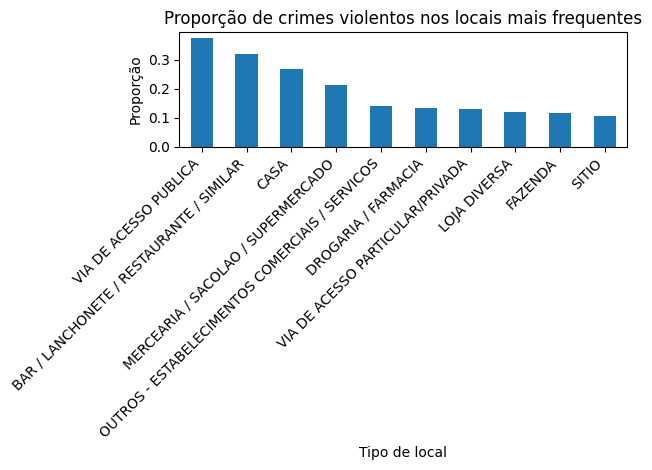

In [34]:
top_freq = resumo_local.sort_values("total_ocorrencias", ascending=False).head(10)

top_freq = top_freq.sort_values("proporcao_violenta", ascending=False)

top_freq["proporcao_violenta"].plot(kind="bar")

plt.title("Proporção de crimes violentos nos locais mais frequentes")
plt.ylabel("Proporção")
plt.xlabel("Tipo de local")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.show()